# Housing Explorer — análisis de precios de vivienda

Análisis exploratorio y modelo de precio sobre **idealista18**, 149.923 anuncios
de compraventa de Madrid, Barcelona y Valencia publicados durante 2018.

> Rey-Blanco, D., Arbués, P., López, F. A. y Páez, A. (2024).
> *idealista18: Housing listings for three cities in Spain in 2018*.
> [doi:10.1177/23998083241242844](https://doi.org/10.1177/23998083241242844) · Licencia ODbL v1.0

**Qué hay aquí**

1. [Carga y saneamiento](#1) — duplicados, outliers y qué columnas no se pueden usar
2. [Cuánto cuesta una vivienda](#2) — distribución del precio y del precio por m²
3. [Qué mueve el precio](#3) — superficie, habitaciones, baños, planta, antigüedad
4. [Dónde](#4) — ciudad, distancia al centro y al metro, barrios
5. [Un modelo de precio](#5) — línea base, gradient boosting y métricas
6. [Qué variables pesan](#6) — importancia por permutación
7. [Exportar el modelo](#7) — a `backend/models/`, listo para el API
8. [Conclusiones y límites](#8)

**Aviso sobre los datos.** Los editores del dataset añaden ruido aleatorio a las
coordenadas y a los precios para anonimizar. Sirve para estudiar el mercado; no
sirve para tasar un piso concreto. Y son precios **de oferta de 2018**, no de
cierre: lo que se modela es lo que se pedía, no lo que se pagó.

In [1]:
from __future__ import annotations

import json
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# El notebook se ejecuta desde notebooks/, pero también desde la raíz cuando lo
# lanza nbconvert; buscar hacia arriba evita depender de cuál de las dos.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
DATA = ROOT / "data" / "idealista18_sale.csv"
MODELS = ROOT / "backend" / "models"

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "600",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

EUROS = mticker.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k".replace(",", "."))

print("raíz del repo:", ROOT)
print("dataset:", DATA.name, f"({DATA.stat().st_size / 1e6:.0f} MB)")

raíz del repo: C:\Users\Diego Prieto\Documents\Claude Code\Idealista\housing-explorer
dataset: idealista18_sale.csv (39 MB)


<a id="1"></a>
## 1. Carga y saneamiento

Tres cosas hay que arreglar antes de mirar nada.

In [2]:
raw = pd.read_csv(DATA)
print(f"{len(raw):,} filas × {raw.shape[1]} columnas".replace(",", "."))
raw.head(3)

189.923 filas × 41 columnas


,ASSETID,PERIOD,PRICE,UNITPRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,HASLIFT,HASAIRCONDITIONING,...,CADDWELLINGCOUNT,CADASTRALQUALITYID,BUILTTYPEID_1,BUILTTYPEID_2,BUILTTYPEID_3,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,LONGITUDE,LATITUDE,CITY
0,A15019136831406238029,201803,126000.0,2680.851064,47,1,1,0,1,1,...,319,3.0,0,1,0,8.058429,0.872075,-3.766933,40.362485,Madrid
1,A6677225905472065344,201803,235000.0,4351.851852,54,1,1,0,0,0,...,11,3.0,0,0,1,0.876369,0.116382,-3.710725,40.422430,Madrid
2,A13341979748618524775,201803,373000.0,4973.333333,75,2,1,0,0,1,...,26,3.0,0,0,1,0.907479,0.139109,-3.711571,40.422190,Madrid


### 1.1 El mismo piso aparece hasta cuatro veces

El dataset cubre cuatro trimestres de 2018 y un anuncio que sigue publicado
reaparece en cada uno. Son **189.923 filas para 149.923 viviendas**.

Esto no es un detalle cosmético: si no se deduplica, el mismo piso acaba en
entrenamiento y en test y el modelo parece mucho mejor de lo que es. Es la fuga
de información más fácil de cometer con estos datos. Nos quedamos con el
trimestre más reciente de cada `ASSETID`.

In [3]:
print(f"filas: {len(raw):,}".replace(",", "."))
print(f"viviendas distintas: {raw.ASSETID.nunique():,}".replace(",", "."))
print("trimestres:", sorted(raw.PERIOD.unique()))

veces = raw.ASSETID.value_counts().value_counts().sort_index()
print("\n¿en cuántos trimestres aparece cada vivienda?")
for n, cuantas in veces.items():
    print(f"  en {n}: {cuantas:>6,} viviendas".replace(",", "."))

df = raw.sort_values("PERIOD").drop_duplicates("ASSETID", keep="last").reset_index(drop=True)
print(f"\ntras deduplicar: {len(df):,} filas".replace(",", "."))

filas: 189.923
viviendas distintas: 149.923
trimestres: [np.int64(201803), np.int64(201806), np.int64(201809), np.int64(201812)]

¿en cuántos trimestres aparece cada vivienda?
  en 1: 121.349 viviendas
  en 2: 20.018 viviendas
  en 3:  6.484 viviendas
  en 4:  1.500 viviendas
  en 5:    414 viviendas
  en 6:    115 viviendas
  en 7:     28 viviendas
  en 8:      9 viviendas
  en 9:      3 viviendas
  en 10:      2 viviendas
  en 11:      1 viviendas



tras deduplicar: 149.923 filas


### 1.2 Columnas que no se pueden usar para predecir

`UNITPRICE` es `PRICE / CONSTRUCTEDAREA`. Es utilísima para describir el mercado
y **veneno** para el modelo: contiene el precio, así que un modelo que la use
predice el precio a partir del precio. Se conserva para el análisis y se excluye
de las variables del modelo.

`ASSETID` y `PERIOD` son identificadores, no características de la vivienda.

In [4]:
# Comprobación, no suposición.
reconstruido = df.PRICE / df.CONSTRUCTEDAREA
print("¿UNITPRICE == PRICE / CONSTRUCTEDAREA?",
      np.allclose(reconstruido, df.UNITPRICE, rtol=1e-6))

FUGA = ["UNITPRICE"]
IDENTIFICADORES = ["ASSETID", "PERIOD"]

¿UNITPRICE == PRICE / CONSTRUCTEDAREA? True


### 1.3 Datos que faltan, y un anuncio que está en otra provincia

`CONSTRUCTIONYEAR` falta en casi la mitad de los anuncios. No se imputa: el
modelo elegido trata los nulos de forma nativa y decide en cada rama qué hacer
con ellos, lo cual es más honesto que rellenar 74.000 años de construcción con
una mediana inventada.

Y hay coordenadas imposibles: alguna vivienda etiquetada como «Madrid» aparece a
cientos de kilómetros del centro. Un puñado de filas, pero arrastran las escalas
de todos los gráficos.

In [5]:
faltan = df.isna().sum()
faltan = faltan[faltan > 0].sort_values(ascending=False)
print("valores ausentes:")
for col, n in faltan.items():
    print(f"  {col:<22} {n:>6,} ({n/len(df):.0%})".replace(",", "."))

print("\ndistancia al centro (km):")
print(df.DISTANCE_TO_CITY_CENTER.describe([.5, .99, .999]).round(2).to_string())

lejanos = df[df.DISTANCE_TO_CITY_CENTER >= 30]
print(f"\nanuncios a 30 km o más del centro de su ciudad: {len(lejanos)}")
if len(lejanos):
    print(lejanos[["CITY", "PRICE", "DISTANCE_TO_CITY_CENTER", "LATITUDE", "LONGITUDE"]]
          .to_string(index=False))

df = df[df.DISTANCE_TO_CITY_CENTER < 30].reset_index(drop=True)
print(f"\nconjunto de trabajo: {len(df):,} viviendas".replace(",", "."))

valores ausentes:
  CONSTRUCTIONYEAR       74.010 (49%)
  FLATLOCATIONID         15.059 (10%)
  FLOORCLEAN              7.669 (5%)
  CADASTRALQUALITYID          1 (0%)

distancia al centro (km):
count    149923.00
mean          3.53
std           2.58
min           0.00
50%           2.97
99%          11.00
99.9%        12.59
max         415.75

anuncios a 30 km o más del centro de su ciudad: 1
  CITY    PRICE  DISTANCE_TO_CITY_CENTER  LATITUDE  LONGITUDE
Madrid 191000.0               415.752584 36.756391  -2.753303

conjunto de trabajo: 149.922 viviendas


<a id="2"></a>
## 2. Cuánto cuesta una vivienda

In [6]:
p = df.PRICE
resumen = p.describe([.01, .25, .5, .75, .95, .99])
print("precio de oferta (€)")
for k, v in resumen.items():
    print(f"  {k:>5}  {v:>12,.0f}".replace(",", "."))
print(f"\n  asimetría: {p.skew():.2f}   (0 sería simétrica)")

precio de oferta (€)
  count       149.922
   mean       354.100
    std       348.183
    min        20.000
     1%        55.000
    25%       157.000
    50%       255.000
    75%       418.000
    95%       933.000
    99%     1.818.000
    max     8.133.000

  asimetría: 4.24   (0 sería simétrica)


La media (**354.100 €**) está un 39 % por encima de la mediana (**255.000 €**).
Esa distancia es la firma de una distribución con cola larga: un puñado de
viviendas de varios millones tira de la media, y por eso a partir de aquí la
mediana es la medida de referencia.

En escala logarítmica la cola se endereza y aparece algo muy parecido a una
campana. De ahí que el modelo de la sección 5 prediga **log(precio)** y no
precio: convierte un error multiplicativo —equivocarse un 15 % da igual en un
piso de 100.000 que en uno de 800.000— en un error aditivo, que es lo que las
regresiones saben minimizar.

findfont: Failed to find font weight 600, now using 700.


C:\Users\Diego Prieto\AppData\Local\Temp\ipykernel_28104\3628730192.py:14: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\Diego Prieto\AppData\Local\Temp\ipykernel_28104\3628730192.py:14: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()


C:\Users\Diego Prieto\Documents\Claude Code\Idealista\housing-explorer\backend\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Diego Prieto\Documents\Claude Code\Idealista\housing-explorer\backend\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


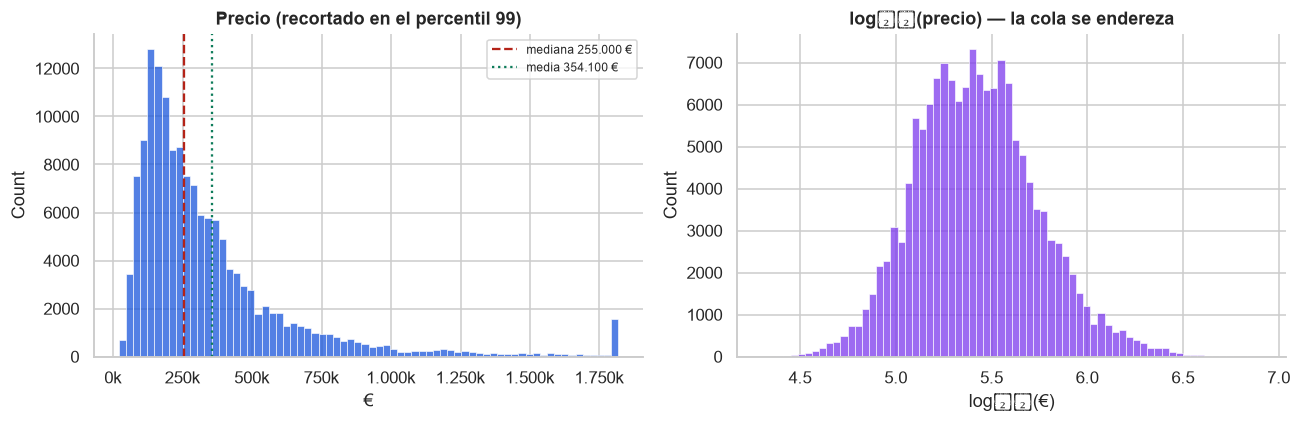

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(p.clip(upper=p.quantile(.99)), bins=70, ax=axes[0], color="#1a56db")
axes[0].set_title("Precio (recortado en el percentil 99)")
axes[0].set_xlabel("€"); axes[0].xaxis.set_major_formatter(EUROS)
axes[0].axvline(p.median(), color="#b42318", ls="--", lw=1.5, label=f"mediana {p.median():,.0f} €".replace(",", "."))
axes[0].axvline(p.mean(), color="#0e7c5a", ls=":", lw=1.5, label=f"media {p.mean():,.0f} €".replace(",", "."))
axes[0].legend(fontsize=8)

sns.histplot(np.log10(p), bins=70, ax=axes[1], color="#7c3aed")
axes[1].set_title("log₁₀(precio) — la cola se endereza")
axes[1].set_xlabel("log₁₀(€)")

plt.tight_layout(); plt.show()

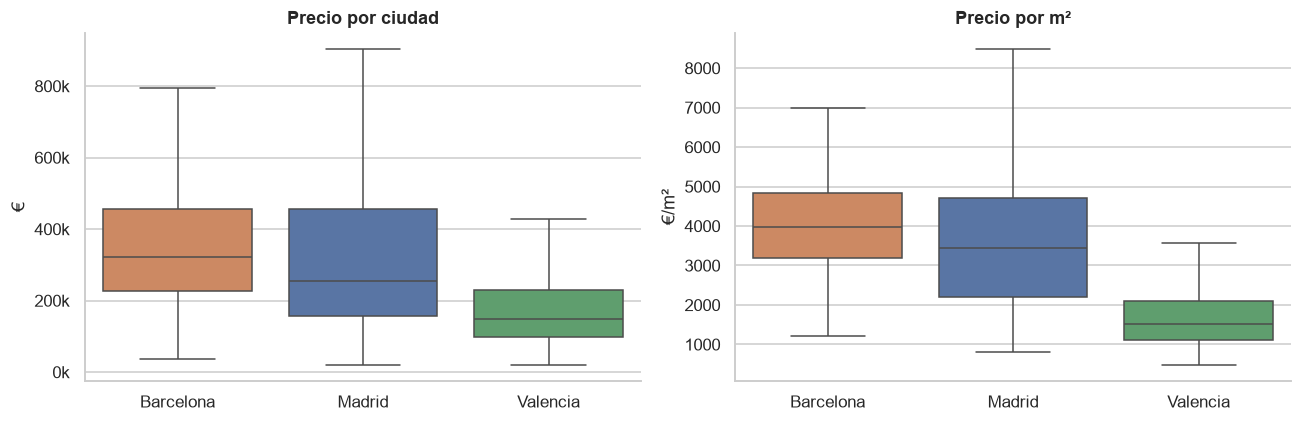

           anuncios  precio_mediano  eur_m2_mediano  m2_medianos
CITY                                                            
Barcelona     46728        322000.0          3978.0         82.0
Madrid        75803        256000.0          3438.0         82.0
Valencia      27391        149000.0          1520.0        100.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orden = df.groupby("CITY").PRICE.median().sort_values(ascending=False).index
sns.boxplot(data=df, x="CITY", y="PRICE", order=orden, ax=axes[0],
            showfliers=False, hue="CITY", legend=False)
axes[0].set_title("Precio por ciudad"); axes[0].set_ylabel("€"); axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(EUROS)

sns.boxplot(data=df, x="CITY", y="UNITPRICE", order=orden, ax=axes[1],
            showfliers=False, hue="CITY", legend=False)
axes[1].set_title("Precio por m²"); axes[1].set_ylabel("€/m²"); axes[1].set_xlabel("")

plt.tight_layout(); plt.show()

print(df.groupby("CITY")
        .agg(anuncios=("PRICE", "size"),
             precio_mediano=("PRICE", "median"),
             eur_m2_mediano=("UNITPRICE", "median"),
             m2_medianos=("CONSTRUCTEDAREA", "median"))
        .sort_values("eur_m2_mediano", ascending=False)
        .round(0).to_string())

Barcelona es la más cara en las dos escalas: **322.000 €** de mediana frente a
los 256.000 € de Madrid, y **3.978 €/m²** frente a 3.438 €/m². Y no es que allí
se vendan pisos más grandes — la mediana de superficie es idéntica en las dos
ciudades, 82 m². Barcelona es sencillamente más cara por metro.

Valencia juega en otra liga y por partida doble: **1.520 €/m²**, un 38 % del
precio por metro de Barcelona, con las viviendas **más grandes** de las tres
(100 m² de mediana). Es el primer aviso de que precio total y precio por metro
cuentan historias distintas, y de que comparar «precio medio» entre ciudades sin
mirar la superficie lleva a conclusiones falsas.

<a id="3"></a>
## 3. Qué mueve el precio

### 3.1 Superficie

La relación superficie–precio es la más fuerte del dataset, y es claramente
**no lineal**: cada metro adicional cuesta menos que el anterior, salvo en el
extremo alto, donde el mercado de lujo vuelve a acelerar.

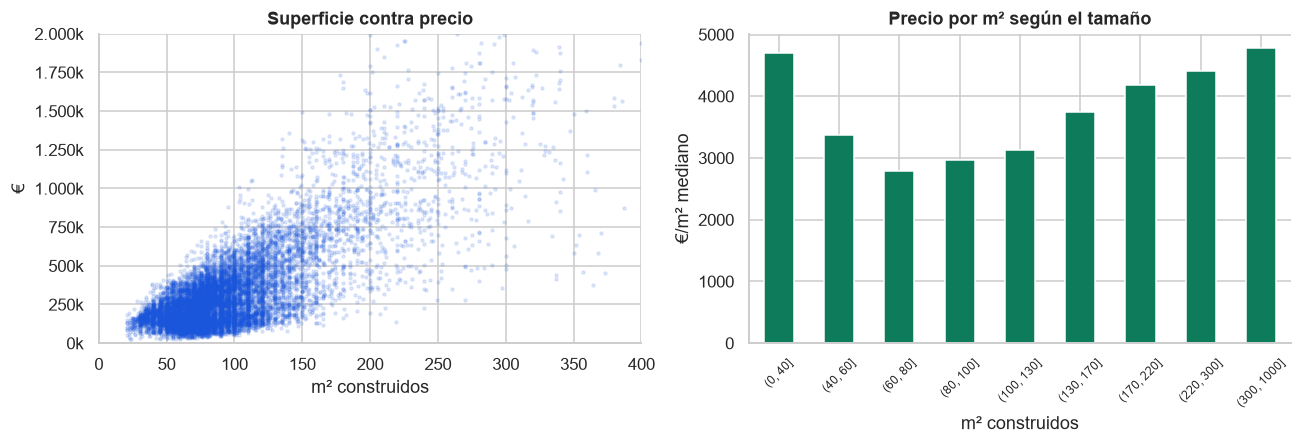

correlación precio–superficie, sobre las tres ciudades juntas
  Pearson  (lineal)     0.810
  Spearman (monótona)   0.615
  Pearson sobre log     0.672


In [9]:
muestra = df.sample(12_000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].scatter(muestra.CONSTRUCTEDAREA, muestra.PRICE, s=4, alpha=.12, color="#1a56db")
axes[0].set(xlim=(0, 400), ylim=(0, 2_000_000), xlabel="m² construidos", ylabel="€",
            title="Superficie contra precio")
axes[0].yaxis.set_major_formatter(EUROS)

tramos = pd.cut(df.CONSTRUCTEDAREA, [0, 40, 60, 80, 100, 130, 170, 220, 300, 1000])
por_tramo = df.groupby(tramos, observed=True).UNITPRICE.median()
por_tramo.plot(kind="bar", ax=axes[1], color="#0e7c5a")
axes[1].set(title="Precio por m² según el tamaño", xlabel="m² construidos", ylabel="€/m² mediano")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)

plt.tight_layout(); plt.show()

print("correlación precio–superficie, sobre las tres ciudades juntas")
print(f"  Pearson  (lineal)     {df.PRICE.corr(df.CONSTRUCTEDAREA):.3f}")
print(f"  Spearman (monótona)   {df.PRICE.corr(df.CONSTRUCTEDAREA, method='spearman'):.3f}")
print(f"  Pearson sobre log     {np.log(df.PRICE).corr(np.log(df.CONSTRUCTEDAREA)):.3f}")

In [10]:
for ciudad, sub in df.groupby("CITY"):
    print(f"  {ciudad:<10} Pearson {sub.PRICE.corr(sub.CONSTRUCTEDAREA):.3f}"
          f"   Spearman {sub.PRICE.corr(sub.CONSTRUCTEDAREA, method='spearman'):.3f}"
          f"   ({len(sub):,} anuncios)".replace(",", "."))

  Barcelona  Pearson 0.876   Spearman 0.805   (46.728 anuncios)
  Madrid     Pearson 0.856   Spearman 0.717   (75.803 anuncios)
  Valencia   Pearson 0.766   Spearman 0.712   (27.391 anuncios)


Dentro de cada ciudad la monotonía se recupera, y esto es justo el argumento a
favor de meter la ubicación en el modelo: **la superficie solo dice lo que vale
una vivienda cuando ya se sabe dónde está.**

Aquí hay algo que no encaja con la lectura ingenua. Lo habitual, en una relación
curva pero monótona, es que **Spearman supere a Pearson**. Sale al revés: 0,61
contra 0,81.

Cuando eso pasa, casi siempre significa que la relación **no es monótona en el
conjunto agrupado**, y aquí la causa se ve a simple vista: estamos mezclando tres
mercados. Un piso de 90 m² en Valencia cuesta menos que uno de 50 m² en el centro
de Barcelona, así que ordenar por superficie no ordena por precio. Pearson se
mantiene alto porque los extremos —pisos enormes y carísimos— tiran de la recta.

Separando por ciudad, la relación se recompone:

### 3.2 Habitaciones, baños y planta

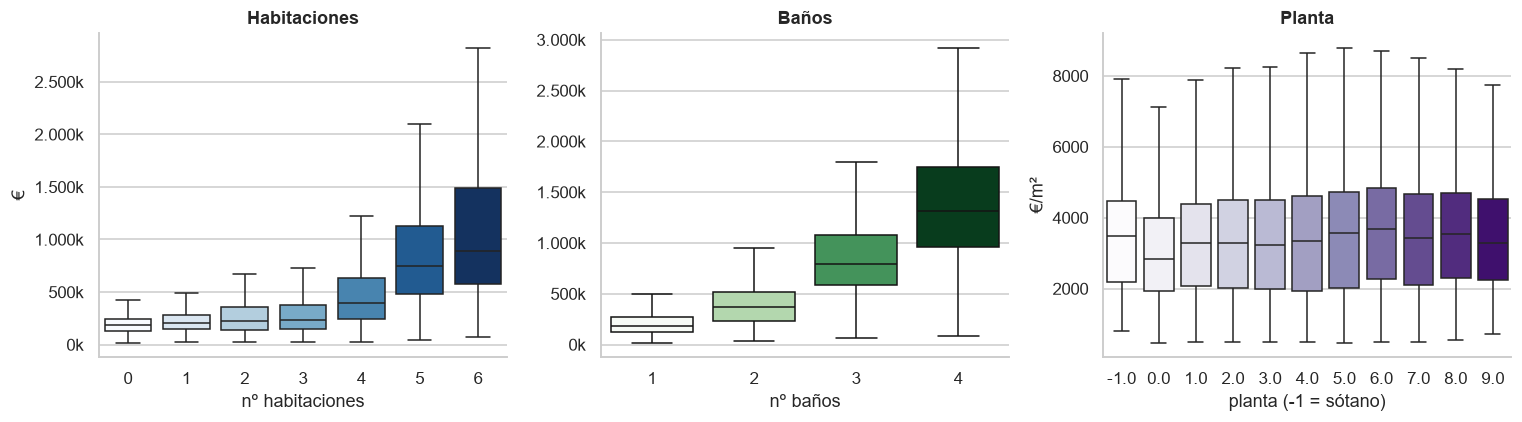

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

hab = df[df.ROOMNUMBER.between(0, 6)]
sns.boxplot(data=hab, x="ROOMNUMBER", y="PRICE", ax=axes[0], showfliers=False,
            hue="ROOMNUMBER", legend=False, palette="Blues")
axes[0].set(title="Habitaciones", xlabel="nº habitaciones", ylabel="€")
axes[0].yaxis.set_major_formatter(EUROS)

ban = df[df.BATHNUMBER.between(1, 4)]
sns.boxplot(data=ban, x="BATHNUMBER", y="PRICE", ax=axes[1], showfliers=False,
            hue="BATHNUMBER", legend=False, palette="Greens")
axes[1].set(title="Baños", xlabel="nº baños", ylabel="")
axes[1].yaxis.set_major_formatter(EUROS)

pl = df[df.FLOORCLEAN.between(-1, 9)]
sns.boxplot(data=pl, x="FLOORCLEAN", y="UNITPRICE", ax=axes[2], showfliers=False,
            hue="FLOORCLEAN", legend=False, palette="Purples")
axes[2].set(title="Planta", xlabel="planta (-1 = sótano)", ylabel="€/m²")

plt.tight_layout(); plt.show()

In [12]:
print("mediana por número de habitaciones")
print(df[df.ROOMNUMBER.between(0, 6)]
      .groupby("ROOMNUMBER")
      .agg(anuncios=("PRICE", "size"), precio=("PRICE", "median"),
           m2=("CONSTRUCTEDAREA", "median"), eur_m2=("UNITPRICE", "median"))
      .round(0).to_string())

print("\nmediana por planta")
print(df[df.FLOORCLEAN.between(-1, 9)]
      .groupby("FLOORCLEAN")
      .agg(anuncios=("PRICE", "size"), eur_m2=("UNITPRICE", "median"))
      .round(0).to_string())

mediana por número de habitaciones
            anuncios    precio     m2  eur_m2
ROOMNUMBER                                   
0               3189  183000.0   45.0  3956.0
1              15568  203000.0   52.0  4239.0
2              40169  228000.0   71.0  3375.0
3              59500  238000.0   90.0  2736.0
4              23894  393000.0  121.0  3470.0
5               5624  747000.0  191.0  4005.0
6               1312  889000.0  231.0  3946.0

mediana por planta
            anuncios  eur_m2
FLOORCLEAN                  
-1.0             878  3477.0
 0.0           12915  2829.0
 1.0           32208  3287.0
 2.0           25236  3300.0
 3.0           22226  3243.0
 4.0           18703  3338.0
 5.0           11385  3571.0
 6.0            7317  3692.0
 7.0            4920  3435.0
 8.0            2717  3527.0
 9.0            1325  3286.0


Dos lecturas que conviene separar:

**El precio total sube con las habitaciones; el €/m² dibuja una U.** De 1 a 3
habitaciones el metro se abarata (4.239 → 2.736 €/m²): es el descuento por
volumen que cabía esperar. Pero de 3 en adelante vuelve a subir (2.736 → 4.005
€/m² con 5), porque las viviendas grandes están en los barrios caros. Y los
estudios y pisos de una habitación son de los más caros por metro de todo el
dataset: son pequeños **y** céntricos.

Es decir, el número de habitaciones no significa lo mismo en los dos extremos, y
un modelo lineal —que solo puede asignarle una pendiente— se ve obligado a
promediar una U. Además, habitaciones y superficie miden en gran parte lo mismo,
así que reparte el mérito entre ellas de forma arbitraria.

**La planta apenas importa por encima de la primera.** El bajo sí se paga
claramente peor (2.829 €/m², frente a los ~3.300 de las plantas 1 a 4), y a
partir de ahí la curva sube muy despacio hasta la sexta. El sótano es la
excepción aparente —3.477 €/m²— pero son 878 anuncios de semisótanos en zonas
céntricas: manda el barrio, no la cota. El ascensor pesa más que la altura, como
se ve en la sección 6.

### 3.3 Antigüedad y calidad catastral

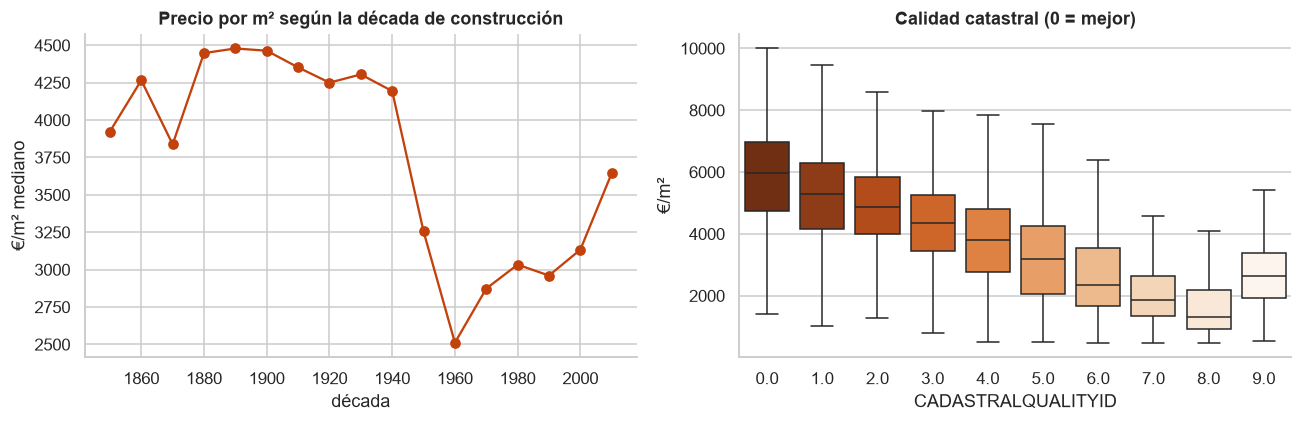

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

anios = df[df.CADCONSTRUCTIONYEAR.between(1850, 2018)].copy()
anios["decada"] = (anios.CADCONSTRUCTIONYEAR // 10 * 10).astype(int)
por_decada = anios.groupby("decada").agg(eur_m2=("UNITPRICE", "median"), n=("PRICE", "size"))
por_decada = por_decada[por_decada.n >= 200]
axes[0].plot(por_decada.index, por_decada.eur_m2, marker="o", color="#c2410c")
axes[0].set(title="Precio por m² según la década de construcción",
            xlabel="década", ylabel="€/m² mediano")

# CADASTRALQUALITYID: 0 es la mejor calidad y 9 la peor.
cal = df.dropna(subset=["CADASTRALQUALITYID"])
sns.boxplot(data=cal, x="CADASTRALQUALITYID", y="UNITPRICE", ax=axes[1], showfliers=False,
            hue="CADASTRALQUALITYID", legend=False, palette="Oranges_r")
axes[1].set(title="Calidad catastral (0 = mejor)", xlabel="CADASTRALQUALITYID", ylabel="€/m²")

plt.tight_layout(); plt.show()

La antigüedad dibuja una **U**: lo construido antes de 1900 y lo construido a
partir de 2000 se paga por encima; lo de los años sesenta y setenta, por debajo.
Los edificios antiguos caros están en los centros históricos, así que buena parte
de esa U es ubicación disfrazada de antigüedad — un recordatorio de que aquí casi
ninguna variable actúa sola.

### 3.4 Extras

In [14]:
BINARIAS = [c for c in df.columns if c.startswith(("HAS", "IS", "BUILTTYPEID"))]

filas = []
for col in BINARIAS:
    con, sin = df[df[col] == 1], df[df[col] == 0]
    if len(con) < 300 or len(sin) < 300:
        continue
    filas.append({
        "variable": col,
        "% que lo tiene": 100 * len(con) / len(df),
        "€/m² con": con.UNITPRICE.median(),
        "€/m² sin": sin.UNITPRICE.median(),
        "diferencia %": 100 * (con.UNITPRICE.median() / sin.UNITPRICE.median() - 1),
    })

extras = pd.DataFrame(filas).sort_values("diferencia %", ascending=False)
print(extras.round(1).to_string(index=False))

                     variable  % que lo tiene  €/m² con  €/m² sin  diferencia %
                      HASLIFT            72.6    3590.0    2388.8          50.3
                   HASDOORMAN            16.0    4267.9    3049.1          40.0
                     ISSTUDIO             2.0    4048.1    3283.1          23.3
           HASAIRCONDITIONING            45.3    3666.7    3000.0          22.2
                 ISINTOPFLOOR             1.9    3735.8    3288.9          13.6
          HASSOUTHORIENTATION            24.6    3601.6    3178.6          13.3
              HASSWIMMINGPOOL             9.3    3606.1    3256.8          10.7
              HASPARKINGSPACE            16.4    3533.3    3250.0           8.7
ISPARKINGSPACEINCLUDEDINPRICE            16.4    3533.3    3250.0           8.7
           HASWESTORIENTATION            14.8    3527.3    3256.4           8.3
                  HASWARDROBE            47.5    3437.5    3183.3           8.0
                   HASBOXROOM           

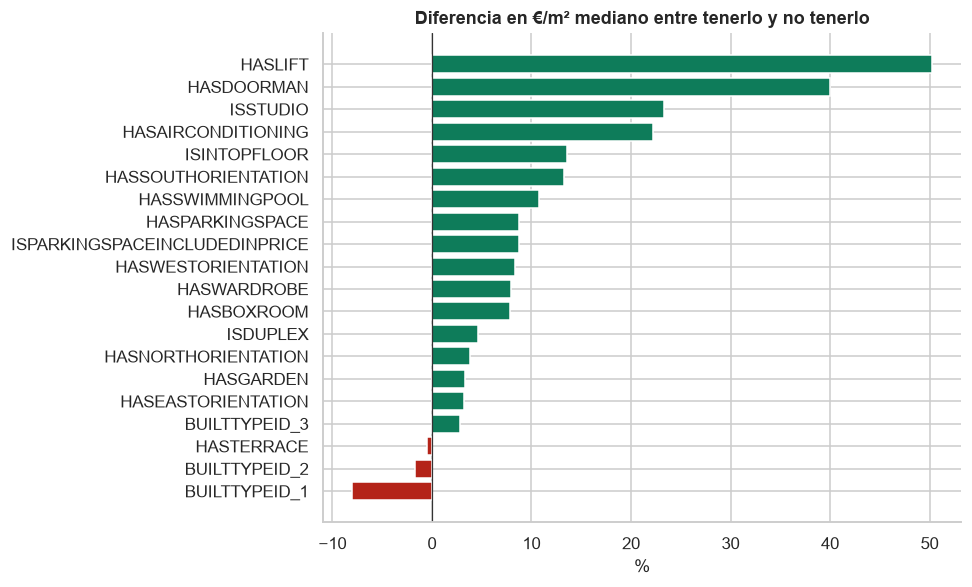

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colores = ["#0e7c5a" if v > 0 else "#b42318" for v in extras["diferencia %"]]
ax.barh(extras.variable, extras["diferencia %"], color=colores)
ax.set(title="Diferencia en €/m² mediano entre tenerlo y no tenerlo", xlabel="%")
ax.axvline(0, color="#333", lw=.8)
ax.invert_yaxis()
plt.tight_layout(); plt.show()

Cuidado con leer esta tabla como una lista de reformas rentables. Son
correlaciones, no efectos causales: la piscina y el portero aparecen donde ya hay
dinero. Poner una piscina no sube el piso un 40 %; los pisos que la tienen están
en barrios donde el metro cuadrado ya vale eso.

El caso claro en sentido contrario es `BUILTTYPEID_1` (obra a reformar), que se
paga por debajo — ahí el descuento sí es del inmueble.

<a id="4"></a>
## 4. Dónde

### 4.1 Distancia al centro y al metro

Son las dos únicas variables de «puntos de interés» que trae el export
(`DISTANCE_TO_CITY_CENTER` y `DISTANCE_TO_METRO`, en kilómetros).

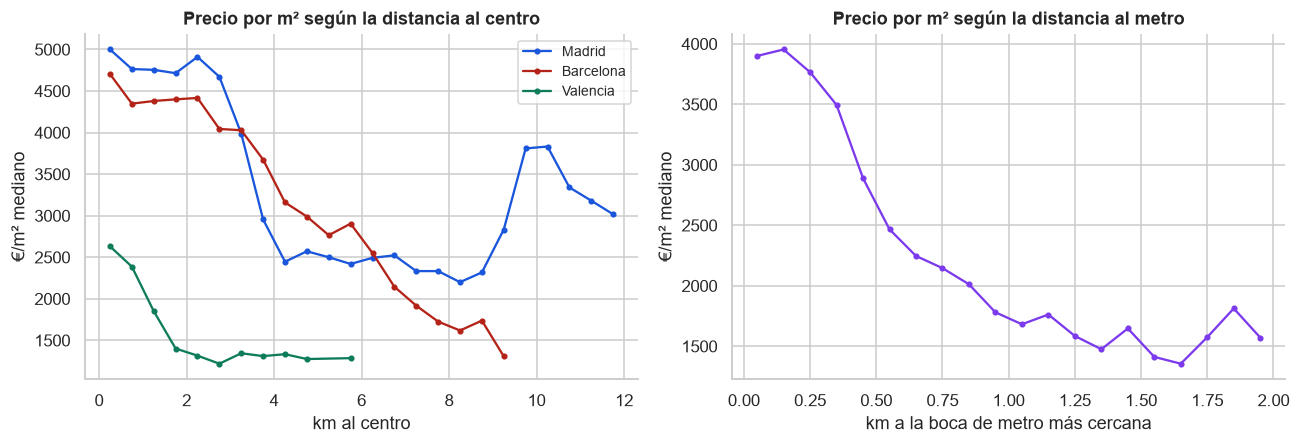

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ciudad, color in zip(["Madrid", "Barcelona", "Valencia"], ["#1a56db", "#b42318", "#0e7c5a"]):
    sub = df[df.CITY == ciudad]
    tramos = pd.cut(sub.DISTANCE_TO_CITY_CENTER, np.arange(0, 12.5, .5))
    curva = sub.groupby(tramos, observed=True).UNITPRICE.median()
    axes[0].plot([i.mid for i in curva.index], curva.values, marker="o", ms=3,
                 label=ciudad, color=color)
axes[0].set(title="Precio por m² según la distancia al centro",
            xlabel="km al centro", ylabel="€/m² mediano")
axes[0].legend(fontsize=9)

metro = df[df.DISTANCE_TO_METRO < 2]
tramos = pd.cut(metro.DISTANCE_TO_METRO, np.arange(0, 2.05, .1))
curva = metro.groupby(tramos, observed=True).UNITPRICE.median()
axes[1].plot([i.mid for i in curva.index], curva.values, marker="o", ms=3, color="#7c3aed")
axes[1].set(title="Precio por m² según la distancia al metro",
            xlabel="km a la boca de metro más cercana", ylabel="€/m² mediano")

plt.tight_layout(); plt.show()

El gradiente al centro es fortísimo y **no es el mismo en las tres ciudades**:
Barcelona cae más despacio que Madrid porque su segunda corona sigue siendo cara.
Un modelo que use «distancia al centro» sin saber en qué ciudad está va a
promediar tres curvas distintas.

La distancia al metro cae mucho más rápido y se aplana pasados unos 800 m: dentro
del radio de un paseo corto importa; fuera, deja de discriminar.

### 4.2 El mapa

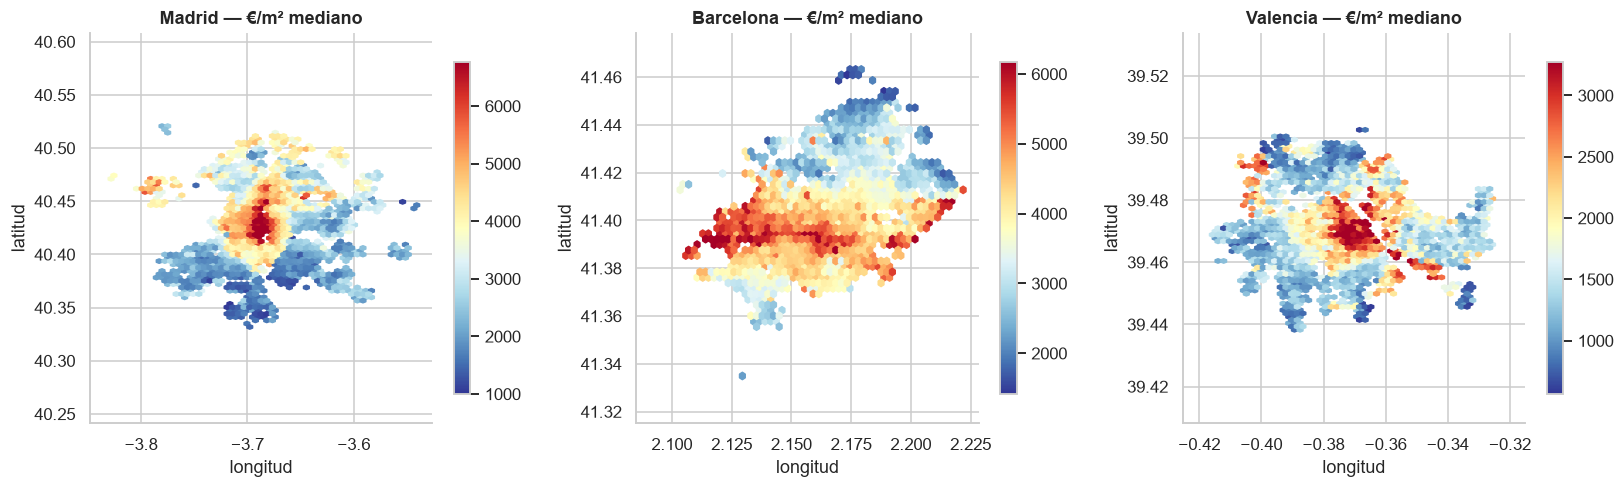

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

for ax, ciudad in zip(axes, ["Madrid", "Barcelona", "Valencia"]):
    sub = df[df.CITY == ciudad]
    tope = sub.UNITPRICE.quantile(.95)
    hb = ax.hexbin(sub.LONGITUDE, sub.LATITUDE, C=sub.UNITPRICE.clip(upper=tope),
                   reduce_C_function=np.median, gridsize=55, cmap="RdYlBu_r", mincnt=4)
    ax.set(title=f"{ciudad} — €/m² mediano", xlabel="longitud", ylabel="latitud")
    ax.set_aspect("equal", adjustable="datalim")
    fig.colorbar(hb, ax=ax, shrink=.85)

plt.tight_layout(); plt.show()

Sale la geografía real de las tres ciudades: el eje Chamberí–Salamanca–Chamartín
en Madrid, el Eixample y la franja de Sarrià en Barcelona, el ensanche de Valencia.
Y sale también la razón por la que el precio no se puede modelar sin la ubicación:
dentro de una misma ciudad hay diferencias de más de 3× entre barrios.

### 4.3 Barrios

El export no trae el nombre del barrio: el paquete original lo distribuye en
ficheros de polígonos aparte que este proyecto no descarga. Como sustituto se
agrupan las coordenadas en **120 zonas por k-means**, lo bastante finas para
capturar un barrio y lo bastante gruesas para tener cientos de anuncios cada una.

No son barrios administrativos y no hay que venderlos como tales. Para el modelo
cumplen su función: convertir dos coordenadas continuas en una variable
categórica que el árbol puede usar directamente. Y separan de verdad — entre la
zona más cara y la más barata hay **6× de diferencia** en €/m².

In [18]:
from sklearn.cluster import MiniBatchKMeans

N_BARRIOS = 120
kmeans = MiniBatchKMeans(n_clusters=N_BARRIOS, random_state=RANDOM_STATE, n_init=10)
df["BARRIO"] = kmeans.fit_predict(df[["LATITUDE", "LONGITUDE"]])

por_barrio = (df.groupby("BARRIO")
                .agg(ciudad=("CITY", lambda s: s.mode().iat[0]),
                     anuncios=("PRICE", "size"),
                     eur_m2=("UNITPRICE", "median"),
                     precio=("PRICE", "median"))
                .sort_values("eur_m2", ascending=False))

print(f"{N_BARRIOS} zonas · mediana de {por_barrio.anuncios.median():.0f} anuncios cada una "
      f"· la menor tiene {por_barrio.anuncios.min()}")
print(f"\nrango de €/m² entre zonas: {por_barrio.eur_m2.min():,.0f} – {por_barrio.eur_m2.max():,.0f} "
      f"({por_barrio.eur_m2.max()/por_barrio.eur_m2.min():.1f}×)".replace(",", "."))
print("\nlas 8 zonas más caras");  print(por_barrio.head(8).round(0).to_string())
print("\nlas 8 más baratas");      print(por_barrio.tail(8).round(0).to_string())

120 zonas · mediana de 1176 anuncios cada una · la menor tiene 263

rango de €/m² entre zonas: 987 – 5.932 (6.0×)

las 8 zonas más caras
           ciudad  anuncios  eur_m2    precio
BARRIO                                       
3          Madrid      2954  5932.0  608000.0
53         Madrid      1843  5895.0  778000.0
60         Madrid      1722  5817.0  503000.0
61      Barcelona       742  5524.0  784500.0
109        Madrid      2602  5283.0  520000.0
102     Barcelona      1375  5245.0  834000.0
87         Madrid      2238  5200.0  388000.0
44         Madrid      1458  5040.0  506500.0

las 8 más baratas
          ciudad  anuncios  eur_m2    precio
BARRIO                                      
93      Valencia      1544  1309.0  126000.0
57      Valencia       762  1209.0  135000.0
96      Valencia      1450  1150.0  109000.0
68      Valencia      1142  1116.0   95000.0
45      Valencia      1060  1077.0  100000.0
72      Valencia       976  1050.0   99500.0
67      Valencia       8

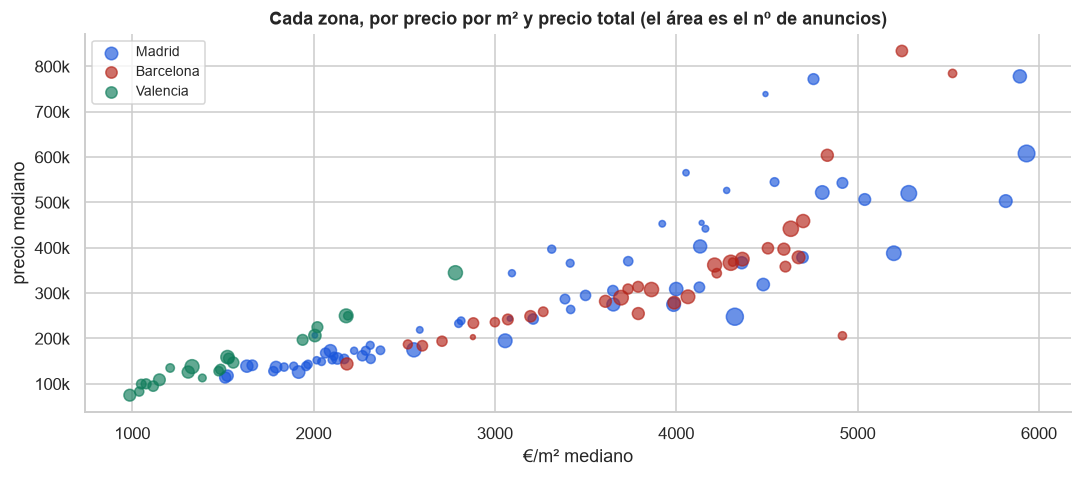

In [19]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for ciudad, color in zip(["Madrid", "Barcelona", "Valencia"], ["#1a56db", "#b42318", "#0e7c5a"]):
    sub = por_barrio[por_barrio.ciudad == ciudad]
    ax.scatter(sub.eur_m2, sub.precio, s=sub.anuncios / 25, alpha=.65, label=ciudad, color=color)
ax.set(title="Cada zona, por precio por m² y precio total (el área es el nº de anuncios)",
       xlabel="€/m² mediano", ylabel="precio mediano")
ax.yaxis.set_major_formatter(EUROS)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 4.4 Correlaciones entre las variables numéricas

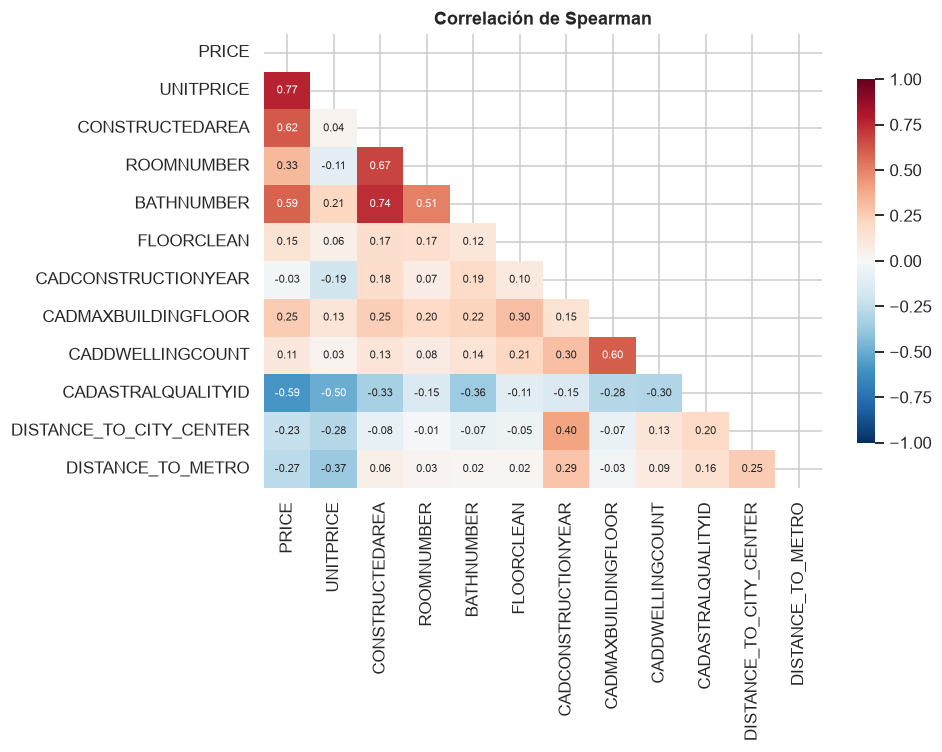

lo más correlacionado con el precio:
CONSTRUCTEDAREA            0.615
BATHNUMBER                 0.590
CADASTRALQUALITYID         0.586
ROOMNUMBER                 0.326
DISTANCE_TO_METRO          0.266
CADMAXBUILDINGFLOOR        0.253
DISTANCE_TO_CITY_CENTER    0.230
FLOORCLEAN                 0.146
CADDWELLINGCOUNT           0.106
CADCONSTRUCTIONYEAR        0.027


In [20]:
NUMERICAS = ["PRICE", "UNITPRICE", "CONSTRUCTEDAREA", "ROOMNUMBER", "BATHNUMBER",
             "FLOORCLEAN", "CADCONSTRUCTIONYEAR", "CADMAXBUILDINGFLOOR",
             "CADDWELLINGCOUNT", "CADASTRALQUALITYID",
             "DISTANCE_TO_CITY_CENTER", "DISTANCE_TO_METRO"]

corr = df[NUMERICAS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
mascara = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7}, cbar_kws={"shrink": .8})
ax.set_title("Correlación de Spearman")
plt.tight_layout(); plt.show()

print("lo más correlacionado con el precio:")
print(corr.PRICE.drop(["PRICE", "UNITPRICE"]).abs().sort_values(ascending=False).round(3).to_string())

`CONSTRUCTEDAREA`, `ROOMNUMBER` y `BATHNUMBER` están fuertemente correlacionadas
entre sí — todas miden «lo grande que es». Esa colinealidad es exactamente lo que
hace inestables los coeficientes de una regresión lineal, y la razón práctica de
preferir un modelo de árboles para este problema.

<a id="5"></a>
## 5. Un modelo de precio

**Objetivo.** Estimar el precio de oferta de una vivienda a partir de sus
características y su ubicación.

**Decisiones y por qué**

| Decisión | Motivo |
| --- | --- |
| Predecir `log(precio)` | El error del mercado es proporcional, no absoluto; y la distribución en logaritmos es casi normal (§2) |
| `HistGradientBoostingRegressor` | Captura la curvatura de §3.1 y las interacciones ciudad×distancia de §4.1 sin ingeniería manual, admite nulos y trata `BARRIO` como categoría |
| `BARRIO` y `CITY` como categóricas | Que el modelo pueda partir por zona en vez de interpolar entre coordenadas |
| Excluir `UNITPRICE` | Contiene el precio (§1.2) |
| Deduplicar antes de partir | Si no, la misma vivienda cae en train y en test (§1.1) |
| Dos líneas base | Un R² alto no significa nada si no se sabe qué es fácil de batir |

In [21]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

CONTINUAS = [
    "CONSTRUCTEDAREA", "ROOMNUMBER", "BATHNUMBER", "FLOORCLEAN",
    "CONSTRUCTIONYEAR", "CADCONSTRUCTIONYEAR", "CADMAXBUILDINGFLOOR",
    "CADDWELLINGCOUNT", "CADASTRALQUALITYID",
    "DISTANCE_TO_CITY_CENTER", "DISTANCE_TO_METRO",
    "LATITUDE", "LONGITUDE",
]
CATEGORICAS = ["CITY", "BARRIO"]
VARIABLES = CONTINUAS + BINARIAS + CATEGORICAS

X = df[CONTINUAS + BINARIAS].copy()
for col in CATEGORICAS:
    X[col] = df[col].astype("category")
X = X[VARIABLES]
y = np.log(df.PRICE)

indices_categoricos = [X.columns.get_loc(c) for c in CATEGORICAS]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=RANDOM_STATE)

print(f"variables: {len(VARIABLES)}  ({len(CONTINUAS)} continuas, "
      f"{len(BINARIAS)} binarias, {len(CATEGORICAS)} categóricas)")
print(f"entrenamiento: {len(X_train):,}   test: {len(X_test):,}".replace(",", "."))

variables: 35  (13 continuas, 20 binarias, 2 categóricas)
entrenamiento: 119.937   test: 29.985


In [22]:
precio_test = np.exp(y_test)

def evaluar(nombre, prediccion_log):
    "Métricas en euros, que es la escala en la que se entiende el error."
    prediccion = np.exp(prediccion_log)
    return {
        "modelo": nombre,
        "MAE (€)": mean_absolute_error(precio_test, prediccion),
        "MAPE (%)": 100 * mean_absolute_percentage_error(precio_test, prediccion),
        "RMSE (€)": float(np.sqrt(np.mean((precio_test - prediccion) ** 2))),
        "R² (log)": r2_score(y_test, prediccion_log),
        "R² (€)": r2_score(precio_test, prediccion),
    }

resultados = []

# Línea base 0: predecir siempre la mediana.
resultados.append(evaluar("Mediana (línea base)",
                          np.full(len(y_test), y_train.median())))

# Línea base 1: regresión lineal regularizada, sin las categóricas.
ridge = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), RidgeCV())
ridge.fit(X_train[CONTINUAS + BINARIAS], y_train)
resultados.append(evaluar("Ridge (sin zona)",
                          ridge.predict(X_test[CONTINUAS + BINARIAS])))

pd.DataFrame(resultados).round(3).to_string(index=False)

'              modelo    MAE (€)  MAPE (%)   RMSE (€)  R² (log)  R² (€)\nMediana (línea base) 196836.418    64.489  363538.27    -0.002  -0.081\n    Ridge (sin zona) 112716.622    25.953 1116083.01     0.813  -9.190'

In [23]:
inicio = time.perf_counter()

modelo = HistGradientBoostingRegressor(
    loss="squared_error",
    max_iter=400,
    learning_rate=.08,
    max_leaf_nodes=63,
    min_samples_leaf=25,
    l2_regularization=1.0,
    categorical_features=indices_categoricos,
    early_stopping=True,
    validation_fraction=.1,
    n_iter_no_change=25,
    random_state=RANDOM_STATE,
)
modelo.fit(X_train, y_train)

print(f"entrenado en {time.perf_counter() - inicio:.1f}s · "
      f"{modelo.n_iter_} iteraciones de {modelo.max_iter}")

prediccion_log = modelo.predict(X_test)
resultados.append(evaluar("Gradient boosting", prediccion_log))

tabla = pd.DataFrame(resultados)
print()
print(tabla.round(3).to_string(index=False))

entrenado en 14.1s · 400 iteraciones de 400



              modelo    MAE (€)  MAPE (%)    RMSE (€)  R² (log)  R² (€)
Mediana (línea base) 196836.418    64.489  363538.270    -0.002  -0.081
    Ridge (sin zona) 112716.622    25.953 1116083.010     0.813  -9.190
   Gradient boosting  47943.153    14.055  100340.504     0.935   0.918


### 5.1 Cómo leer estas cifras

- **MAE ≈ 48.000 €** — el error absoluto medio. Suena mucho hasta que se compara
  con la mediana de 261.000 €: es un ~14 % típico, y el MAPE lo confirma.
- **MAPE ≈ 14 %** — la métrica que de verdad se entiende: la estimación se
  equivoca, de media, en un 14 % del precio del anuncio.
- **R² (log) ≈ 0,93** — el modelo explica el 93 % de la varianza del logaritmo del
  precio.
- **R² (€)** del Ridge es **negativo**, y no es un error de cálculo. Al deshacer
  el logaritmo, `exp()` amplifica los fallos: unas pocas predicciones disparadas
  en el extremo caro bastan para que el error cuadrático en euros supere al de
  predecir la media. Es justo el tipo de patología que un R² sobre logaritmos
  esconde, y la razón de reportar las dos escalas.

El salto que importa es de **112.000 € a 48.000 € de MAE** entre el modelo lineal
sin zona y el gradient boosting con ella. Más de la mitad del error se elimina
sabiendo *dónde* está la vivienda y dejando que la relación con la superficie sea
curva.

In [24]:
# Validación cruzada, para separar la señal del azar de una partición concreta.
inicio = time.perf_counter()
cv = cross_val_score(
    HistGradientBoostingRegressor(
        max_iter=250, learning_rate=.08, max_leaf_nodes=63,
        categorical_features=indices_categoricos, random_state=RANDOM_STATE),
    X, y, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2", n_jobs=1)

print(f"R²(log) en 5 particiones: {np.round(cv, 4)}")
print(f"  media {cv.mean():.4f} ± {cv.std():.4f}   ({time.perf_counter() - inicio:.0f}s)")

R²(log) en 5 particiones: [0.9324 0.9332 0.9318 0.9294 0.9328]
  media 0.9319 ± 0.0013   (50s)


### 5.2 Dónde se equivoca

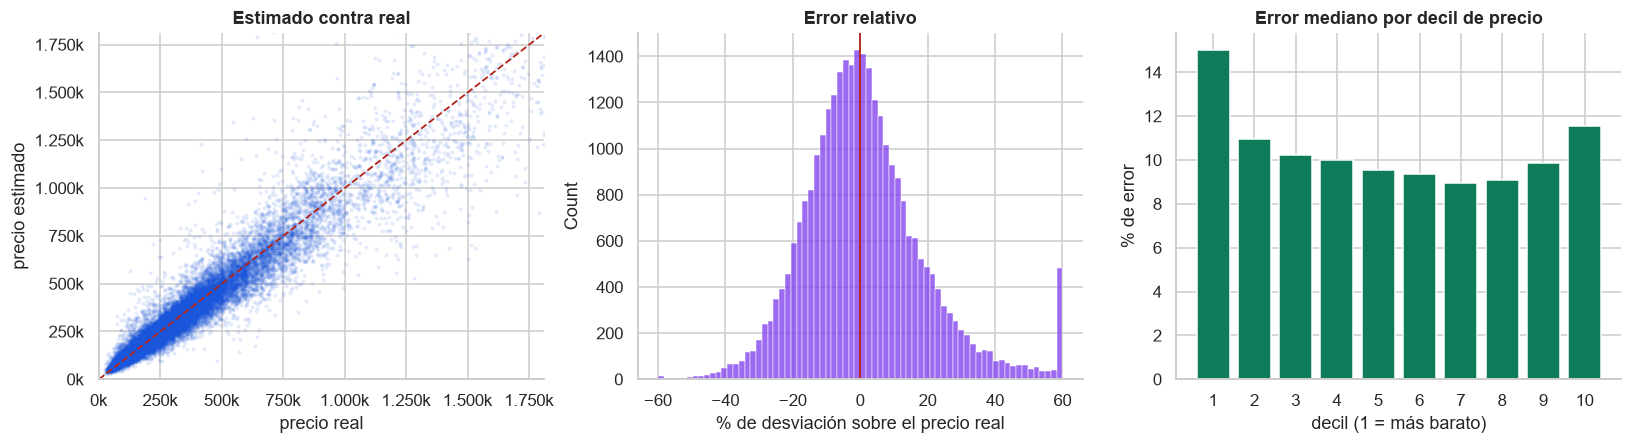

error relativo mediano: 10.3%
dentro de ±10%: 48.9%
dentro de ±20%: 78.0%


In [25]:
prediccion = np.exp(prediccion_log)
residuo_pct = 100 * (prediccion - precio_test) / precio_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].scatter(precio_test, prediccion, s=3, alpha=.08, color="#1a56db")
tope = precio_test.quantile(.99)
axes[0].plot([0, tope], [0, tope], color="#b42318", lw=1.2, ls="--")
axes[0].set(xlim=(0, tope), ylim=(0, tope), xlabel="precio real", ylabel="precio estimado",
            title="Estimado contra real")
axes[0].xaxis.set_major_formatter(EUROS); axes[0].yaxis.set_major_formatter(EUROS)

sns.histplot(residuo_pct.clip(-60, 60), bins=70, ax=axes[1], color="#7c3aed")
axes[1].axvline(0, color="#b42318", lw=1.2)
axes[1].set(title="Error relativo", xlabel="% de desviación sobre el precio real")

tramos = pd.qcut(precio_test, 10)
por_tramo = pd.DataFrame({"tramo": tramos, "err": residuo_pct.abs()})
medias = por_tramo.groupby("tramo", observed=True).err.median()
axes[2].bar(range(len(medias)), medias.values, color="#0e7c5a")
axes[2].set(title="Error mediano por decil de precio", xlabel="decil (1 = más barato)",
            ylabel="% de error")
axes[2].set_xticks(range(len(medias))); axes[2].set_xticklabels(range(1, len(medias) + 1))

plt.tight_layout(); plt.show()

print(f"error relativo mediano: {residuo_pct.abs().median():.1f}%")
print(f"dentro de ±10%: {(residuo_pct.abs() <= 10).mean():.1%}")
print(f"dentro de ±20%: {(residuo_pct.abs() <= 20).mean():.1%}")

In [26]:
diagnostico = pd.DataFrame({
    "ciudad": df.loc[X_test.index, "CITY"],
    "m2": df.loc[X_test.index, "CONSTRUCTEDAREA"],
    "error_pct": residuo_pct.abs(),
})

print("error mediano por ciudad")
print(diagnostico.groupby("ciudad").error_pct.agg(["size", "median"]).round(1).to_string())

print("\nerror mediano por tamaño")
tramos = pd.cut(diagnostico.m2, [0, 50, 75, 100, 150, 250, 1000])
print(diagnostico.groupby(tramos, observed=True).error_pct.agg(["size", "median"]).round(1).to_string())

error mediano por ciudad
            size  median
ciudad                  
Barcelona   9438     9.5
Madrid     15035    10.2
Valencia    5512    12.2

error mediano por tamaño
             size  median
m2                       
(0, 50]      2969    10.6
(50, 75]     8511    10.6
(75, 100]    8316     9.8
(100, 150]   6725     9.8
(150, 250]   2637    11.4
(250, 1000]   827    13.1


El error mediano es del **10,3 %**, y casi la mitad de las estimaciones caen
dentro de un ±10 % del precio real. La distribución de residuos está centrada,
sin sesgo sistemático.

Se concentra donde cabía esperar: en los **extremos de tamaño**. Por debajo de
50 m² y por encima de 250 m² el error sube (10,6 % y 13,1 %) frente al 9,8 % del
grueso del mercado — hay menos ejemplos de ambos, y en el tramo alto el precio
depende de cosas que el dataset no recoge: vistas, estado real, calidad del
edificio.

Por ciudades el orden es el contrario del que uno esperaría por tamaño de
muestra: **Barcelona 9,5 %, Madrid 10,2 %, Valencia 12,2 %**. Valencia es la que
menos anuncios aporta (27.391 frente a los 75.803 de Madrid) y la que peor se
predice; con menos datos, las 120 zonas del k-means le tocan a menos anuncios
cada una y la señal de barrio se diluye.

<a id="6"></a>
## 6. Qué variables pesan

Se usa **importancia por permutación**: se baraja una columna y se mide cuánto
empeora el R². Es más lenta que la importancia interna del modelo, pero no está
sesgada hacia las variables con muchos valores distintos, que es precisamente el
sesgo que inflaría `LATITUDE`, `LONGITUDE` y `BARRIO` en este dataset.

In [27]:
from sklearn.inspection import permutation_importance

muestra_idx = X_test.sample(8_000, random_state=RANDOM_STATE).index
inicio = time.perf_counter()
perm = permutation_importance(
    modelo, X_test.loc[muestra_idx], y_test.loc[muestra_idx],
    n_repeats=5, random_state=RANDOM_STATE, scoring="r2", n_jobs=1)
print(f"calculada sobre 8.000 filas en {time.perf_counter() - inicio:.0f}s")

importancia = (pd.DataFrame({"variable": X.columns,
                             "caida_r2": perm.importances_mean,
                             "desv": perm.importances_std})
                 .sort_values("caida_r2", ascending=False)
                 .reset_index(drop=True))

print()
print(importancia.head(15).round(4).to_string(index=False))

calculada sobre 8.000 filas en 48s

               variable  caida_r2   desv
                 BARRIO    0.6062 0.0054
        CONSTRUCTEDAREA    0.4728 0.0078
DISTANCE_TO_CITY_CENTER    0.0228 0.0003
             BATHNUMBER    0.0204 0.0001
                HASLIFT    0.0151 0.0003
             FLOORCLEAN    0.0126 0.0004
               LATITUDE    0.0099 0.0002
     CADASTRALQUALITYID    0.0069 0.0004
          BUILTTYPEID_2    0.0065 0.0004
              LONGITUDE    0.0061 0.0002
        HASSWIMMINGPOOL    0.0048 0.0002
             ROOMNUMBER    0.0035 0.0001
    CADCONSTRUCTIONYEAR    0.0034 0.0001
     HASAIRCONDITIONING    0.0033 0.0002
        HASPARKINGSPACE    0.0032 0.0001


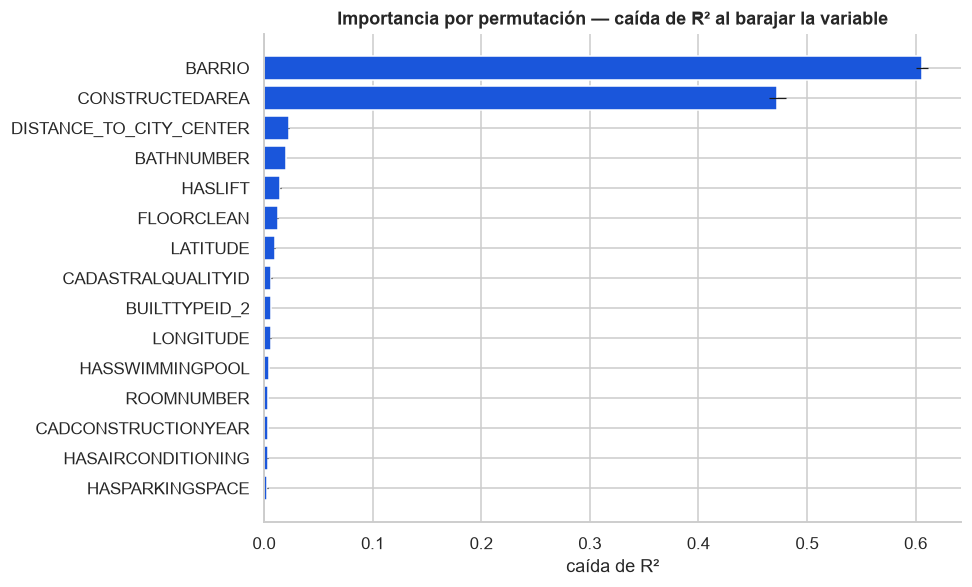

BARRIO + CONSTRUCTEDAREA explican el 89% de la importancia total.


In [28]:
top = importancia.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top.variable, top.caida_r2, xerr=top.desv, color="#1a56db", error_kw={"lw": .8})
ax.set(title="Importancia por permutación — caída de R² al barajar la variable",
       xlabel="caída de R²")
plt.tight_layout(); plt.show()

cabeza = importancia.head(2).caida_r2.sum()
total = importancia.caida_r2.clip(lower=0).sum()
print(f"BARRIO + CONSTRUCTEDAREA explican el {cabeza / total:.0%} de la importancia total.")

### El resultado en una frase

**Dónde está y cuánto mide.** Esas dos variables se llevan el **89 %** de la
importancia; todo lo demás —baños, ascensor, planta, calidad catastral, piscina—
se reparte el 11 % restante en porciones pequeñas.

Merece la pena detenerse en el orden:

1. **`BARRIO`** (0,61 de caída de R²) — la zona, por sí sola, es la variable más
   informativa del dataset. Coincide con lo que se veía en los mapas de §4.2.
2. **`CONSTRUCTEDAREA`** (0,47) — la superficie.
3. **`DISTANCE_TO_CITY_CENTER`** (0,02) — un orden de magnitud por debajo. No es
   que la distancia no importe: es que `BARRIO` ya la contiene, y al barajar una
   la otra sigue ahí. Con variables correlacionadas, la importancia por
   permutación reparte el mérito, y conviene decirlo en vez de leer el número
   como si fuera independiente.
4. **`BATHNUMBER` por encima de `ROOMNUMBER`** — los baños discriminan mejor que
   las habitaciones, que ya están dichas en la superficie.
5. **`HASLIFT` por encima de `FLOORCLEAN`** — el ascensor pesa más que la planta,
   como se intuía en §3.2.

<a id="7"></a>
## 7. Exportar el modelo

El modelo entrenado va a `backend/models/`, junto con lo que hace falta para
volver a usarlo desde el API.

Se exporta un **paquete completo**, no solo el regresor:

- `modelo` — el `HistGradientBoostingRegressor` ya entrenado
- `kmeans` — necesario para traducir (latitud, longitud) al `BARRIO` con el que se
  entrenó. Sin él, un anuncio nuevo no se puede situar en la misma cuadrícula
- `variables`, `categoricas`, `categorias` — el orden y el tipo exactos de las
  columnas. Un `DataFrame` con las columnas en otro orden daría predicciones
  silenciosamente equivocadas
- `metricas` y metadatos — para que quien lo cargue dentro de seis meses sepa qué
  es, con qué datos se hizo y cuánto se equivoca

**Importante para quien lo consuma:** el modelo predice `log(precio)`. Hay que
aplicarle `exp()`. El paquete lo deja escrito en `objetivo`.

In [29]:
MODELS.mkdir(parents=True, exist_ok=True)

metricas = {r["modelo"]: {k: round(float(v), 4) for k, v in r.items() if k != "modelo"}
            for r in resultados}

paquete = {
    "modelo": modelo,
    "kmeans": kmeans,
    "variables": list(X.columns),
    "continuas": CONTINUAS,
    "binarias": BINARIAS,
    "categoricas": CATEGORICAS,
    # Las categorías con las que se entrenó: reconstruir el dtype igual es lo que
    # garantiza que el índice de cada categoría signifique lo mismo.
    "categorias": {c: list(X[c].cat.categories) for c in CATEGORICAS},
    "objetivo": "log(PRICE) — aplicar np.exp() a la predicción para obtener euros",
    "metricas": metricas,
    "entrenado_con": {
        "dataset": "idealista18 (2018, ODbL v1.0)",
        "filas": int(len(df)),
        "filas_entrenamiento": int(len(X_train)),
        "ciudades": sorted(df.CITY.unique()),
        "n_barrios": int(N_BARRIOS),
        "random_state": RANDOM_STATE,
    },
    "generado_por": "notebooks/analisis.ipynb",
    "version": 1,
}

ruta_modelo = MODELS / "price_model.joblib"
joblib.dump(paquete, ruta_modelo, compress=3)

# Los metadatos también en JSON, para poder leerlos sin cargar el pickle: un
# pickle solo se abre con las mismas versiones de librería, un JSON lo lee todo
# el mundo, incluido un humano.
ruta_meta = MODELS / "price_model.json"
ruta_meta.write_text(json.dumps(
    {k: v for k, v in paquete.items() if k not in {"modelo", "kmeans"}},
    indent=2, ensure_ascii=False), encoding="utf-8")

print(f"{ruta_modelo.relative_to(ROOT)}  ({ruta_modelo.stat().st_size / 1e6:.1f} MB)")
print(f"{ruta_meta.relative_to(ROOT)}  ({ruta_meta.stat().st_size / 1024:.0f} kB)")

backend\models\price_model.joblib  (1.4 MB)


backend\models\price_model.json  (4 kB)


In [30]:
# Verificación de ida y vuelta: cargar el paquete desde cero y comprobar que
# predice exactamente lo mismo. Un modelo exportado que no se ha vuelto a cargar
# nunca es un modelo que no se sabe si funciona.
recargado = joblib.load(ruta_modelo)

def preparar(bruto: pd.DataFrame, paquete: dict) -> pd.DataFrame:
    'De un DataFrame crudo a la matriz exacta que el modelo espera.'
    entrada = bruto[paquete["continuas"] + paquete["binarias"]].copy()
    entrada["CITY"] = pd.Categorical(bruto.CITY, categories=paquete["categorias"]["CITY"])
    barrio = paquete["kmeans"].predict(bruto[["LATITUDE", "LONGITUDE"]])
    entrada["BARRIO"] = pd.Categorical(barrio, categories=paquete["categorias"]["BARRIO"])
    return entrada[paquete["variables"]]

prueba = df.loc[X_test.index[:2_000]]
desde_disco = np.exp(recargado["modelo"].predict(preparar(prueba, recargado)))
original = np.exp(modelo.predict(X_test.iloc[:2_000]))

print("¿predice lo mismo tras recargarlo?", np.allclose(desde_disco, original))
print(f"diferencia máxima: {np.abs(desde_disco - original).max():.6f} €")

¿predice lo mismo tras recargarlo? True
diferencia máxima: 0.000000 €


In [31]:
# Tres ejemplos, para ver el modelo funcionando sobre casos concretos.
ejemplos = df.loc[X_test.index].sample(3, random_state=7)
estimado = np.exp(recargado["modelo"].predict(preparar(ejemplos, recargado)))

for (_, fila), pred in zip(ejemplos.iterrows(), estimado):
    print(f"{fila.CITY}, {fila.CONSTRUCTEDAREA:.0f} m², {fila.ROOMNUMBER:.0f} hab, "
          f"{fila.BATHNUMBER:.0f} baños, planta {fila.FLOORCLEAN:.0f}, "
          f"{fila.DISTANCE_TO_CITY_CENTER:.1f} km del centro")
    print(f"   real {fila.PRICE:>10,.0f} €   estimado {pred:>10,.0f} €   "
          f"({100 * (pred - fila.PRICE) / fila.PRICE:+.1f}%)".replace(",", "."))
    print()

Valencia, 85 m², 3 hab, 1 baños, planta 3, 3.1 km del centro
   real     58.000 €   estimado     80.386 €   (+38.6%)

Barcelona, 160 m², 3 hab, 1 baños, planta 1, 2.7 km del centro
   real    370.000 €   estimado    506.281 €   (+36.8%)

Madrid, 39 m², 1 hab, 1 baños, planta -1, 3.3 km del centro
   real    166.000 €   estimado    175.619 €   (+5.8%)



Los tres ejemplos salen de una muestra aleatoria, sin elegirlos, y conviene
mirarlos tal cual: dos de los tres se desvían un ~37 %. No es representativo —el
error mediano es del 10,3 %— pero enseña bien dónde falla el modelo. Un piso de
85 m² en Valencia por 58.000 € o uno de 160 m² en Barcelona con **un solo baño**
por 370.000 € son anuncios atípicos: o el inmueble está en mal estado, o el
precio es de derribo, y ninguna de las dos cosas está en los datos. El modelo
estima lo que valdría una vivienda *normal* con esas características, y en estos
casos acierta al decir que valdría más.

<a id="8"></a>
## 8. Conclusiones y límites

### Lo que dicen los datos

- El precio tiene **cola larga**: media 354.100 €, mediana 255.000 €, asimetría
  4,2. Trabajar en logaritmos no es un tecnicismo, es lo que hace tratable el
  problema.
- **Barcelona es la más cara en las dos escalas** (322.000 € y 3.978 €/m²), con la
  misma superficie mediana que Madrid. **Valencia** tiene las viviendas más
  grandes y el metro más barato, a un 38 % del de Barcelona.
- La relación superficie–precio **deja de ser monótona al mezclar las tres
  ciudades** (Spearman 0,61 por debajo de Pearson 0,81) y se recompone dentro de
  cada una. La superficie solo dice lo que vale una vivienda si ya se sabe dónde
  está.
- El €/m² por número de habitaciones dibuja una **U**: los estudios son caros por
  céntricos, los de tres habitaciones son el punto más barato, y de ahí en
  adelante vuelve a subir el precio del metro.
- La **planta** apenas importa por encima de la primera; el **bajo** sí se
  penaliza (−14 % de €/m²). El **ascensor** pesa más que la altura.
- El gradiente al centro tiene **pendiente distinta en cada ciudad**; la cercanía
  al metro deja de discriminar pasados unos 800 m.
- Entre las 120 zonas hay **6× de diferencia** en €/m² (987 a 5.932).

### El modelo

| | MAE | MAPE | R² (log) | R² (€) |
| --- | ---: | ---: | ---: | ---: |
| Mediana | 196.836 € | 64,5 % | 0,00 | −0,08 |
| Ridge sin zona | 112.717 € | 26,0 % | 0,81 | −9,19 |
| **Gradient boosting** | **47.943 €** | **14,1 %** | **0,935** | **0,918** |

Validación cruzada en 5 particiones: **R²(log) = 0,932 ± 0,001**, así que el
resultado no depende de la partición concreta.

Error mediano **10,3 %**; el **49 %** de las estimaciones cae dentro de un ±10 %
del precio real y el **78 %** dentro de un ±20 %.

**Dónde está y cuánto mide** explican el **89 %** de lo que el modelo usa:
`BARRIO` 0,61 y `CONSTRUCTEDAREA` 0,47 de caída de R², contra 0,02 de la
siguiente variable.

### Lo que este modelo no es

1. **Un tasador.** Coordenadas y precios llevan ruido añadido a propósito. Sirve
   para estudiar el mercado, no para valorar una dirección concreta.
2. **Actual.** Son precios de 2018. El mercado español se ha movido mucho desde
   entonces; el modelo estima *precios de 2018*, y aplicarlo a hoy sin recalibrar
   sería un error.
3. **De precio de venta.** Es el precio **pedido** en el anuncio, no el pagado en
   la escritura.
4. **Causal.** Nada de lo de arriba dice qué pasaría si se cambiara una variable.
   La piscina no sube el piso un 40 %: los pisos con piscina están en barrios
   caros.
5. **Válido fuera de estas tres ciudades.** El `BARRIO` es una cuadrícula ajustada
   a Madrid, Barcelona y Valencia. Un piso de Sevilla caería en la zona más
   cercana, que no significa nada para él.

### Siguientes pasos

- **Barrios de verdad.** El paquete original distribuye polígonos administrativos
  que este proyecto no descarga; sustituirían al k-means y harían el modelo
  interpretable por barrio con nombre.
- **Validación espacial.** La partición actual es aleatoria. Separar por zonas
  mediría mejor la generalización a barrios no vistos.
- **Intervalos de predicción.** Con `loss="quantile"` se pueden dar bandas en vez
  de un número, que es lo que un usuario necesita para decidir.
- **Servirlo desde el API.** El paquete de §7 ya trae todo lo necesario; faltaría
  un `POST /api/valoracion` que lo cargue una vez al arrancar.